In [ ]:
import kagglehub
import tensorflow as tf
import os

# загрузка датасета
path = kagglehub.dataset_download("alessiocorrado99/animals10")

# путь
data_dir = os.path.join(path, "raw-img")

# параметры
IMG_SIZE = (128, 128)
BATCH_SIZE = 64
SEED = 42

train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)
val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# классы
class_names = train_ds.class_names
num_classes = len(class_names)

print("Размер:", IMG_SIZE)
print("Batch:", BATCH_SIZE)
print("Классы:", class_names)

Using Colab cache for faster access to the 'animals10' dataset.
Found 26179 files belonging to 10 classes.
Using 20944 files for training.
Found 26179 files belonging to 10 classes.
Using 5235 files for validation.
Размер: (128, 128)
Batch: 64
Классы: ['cane', 'cavallo', 'elefante', 'farfalla', 'gallina', 'gatto', 'mucca', 'pecora', 'ragno', 'scoiattolo']


In [ ]:
#предобаротка

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import time

from tensorflow.keras import layers, models
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score

AUTO = tf.data.AUTOTUNE
def prepare_batch(img, cls):
    img = tf.image.convert_image_dtype(img, tf.float32)
    return img, cls
train_prepared = train_ds.map(prepare_batch, num_parallel_calls=AUTO)
val_prepared = val_ds.map(prepare_batch, num_parallel_calls=AUTO)

train_prepared = (
    train_prepared
    .cache()
    .shuffle(1200, seed=SEED)
    .prefetch(AUTO)
)

val_prepared = (
    val_prepared
    .cache()
    .prefetch(AUTO)
)

train_ds = train_prepared
val_ds = val_prepared

print("Данные подготовлены: изображения приведены к float32 и диапазону [0, 1]")

Данные подготовлены: изображения приведены к float32 и диапазону [0, 1]



На данном этапе была выполнена загрузка и предварительная обработка датасета Animals-10.
Датасет содержит 10 классов цветных RGB-изображений животных.
Изображения были приведены к единому размеру 128×128 пикселей, а значения пикселей нормализованы к диапазону [0, 1].


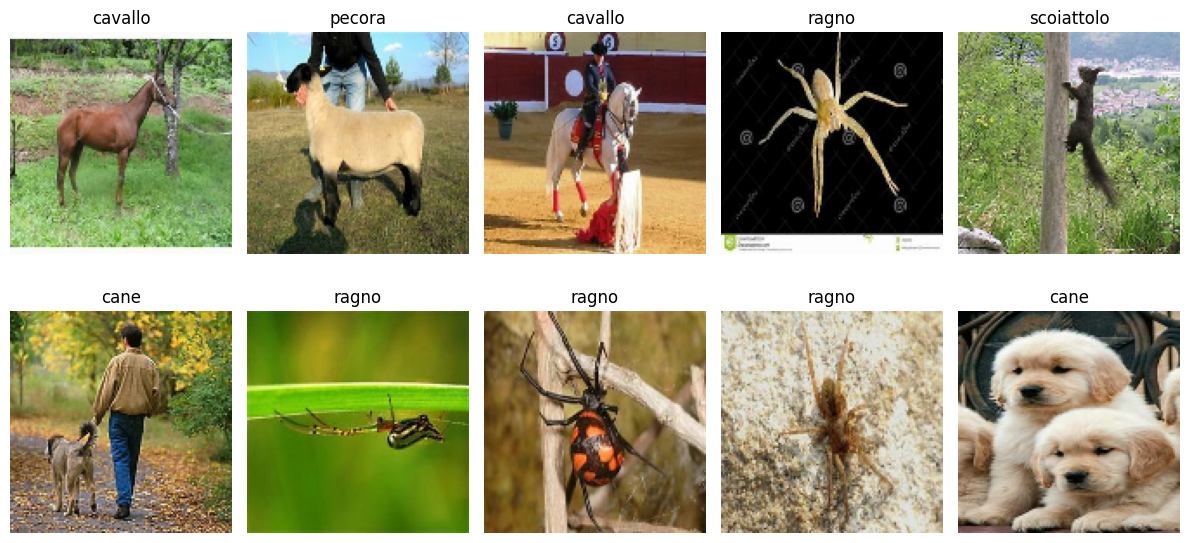

In [ ]:
#визуал

import matplotlib.pyplot as plt
import tensorflow as tf

fig = plt.figure(figsize=(12, 6))
imgs, lbls = next(iter(train_ds))
for idx in range(10):
    ax = fig.add_subplot(2, 5, idx + 1)
    img = imgs[idx]

    if tf.reduce_max(img) > 1:
        img = img / 255.0

    img = tf.clip_by_value(img, 0.0, 1.0)
    ax.imshow(img)
    ax.set_title(class_names[int(lbls[idx])])
    ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
#проектирование

base_input = layers.Input(shape=(*IMG_SIZE, 3))

# аугментация
x = layers.RandomFlip("horizontal")(base_input)
x = layers.RandomRotation(0.05)(x)
x = layers.RandomZoom(0.05)(x)

#
x = layers.Conv2D(32, 3, padding="same")(x)
x = layers.BatchNormalization()(x)
x = layers.ReLU()(x)
x = layers.Conv2D(32, 3, padding="same")(x)
x = layers.BatchNormalization()(x)
x = layers.ReLU()(x)
x = layers.MaxPooling2D()(x)
x = layers.Dropout(0.15)(x)

#
x = layers.Conv2D(64, 3, padding="same")(x)
x = layers.BatchNormalization()(x)
x = layers.ReLU()(x)
x = layers.Conv2D(64, 3, padding="same")(x)
x = layers.BatchNormalization()(x)
x = layers.ReLU()(x)
x = layers.MaxPooling2D()(x)
x = layers.Dropout(0.20)(x)

#
x = layers.Conv2D(128, 3, padding="same")(x)
x = layers.BatchNormalization()(x)
x = layers.ReLU()(x)
x = layers.Conv2D(128, 3, padding="same")(x)
x = layers.BatchNormalization()(x)
x = layers.ReLU()(x)
x = layers.MaxPooling2D()(x)
x = layers.Dropout(0.30)(x)

# доп слой
x = layers.Conv2D(192, 3, padding="same")(x)
x = layers.BatchNormalization()(x)
x = layers.ReLU()(x)

# сжатие признаков
x = layers.GlobalAveragePooling2D()(x)

# классификатор
x = layers.Dense(256)(x)
x = layers.BatchNormalization()(x)
x = layers.ReLU()(x)
x = layers.Dropout(0.45)(x)

x = layers.Dense(128)(x)
x = layers.BatchNormalization()(x)
x = layers.ReLU()(x)
x = layers.Dropout(0.35)(x)

base_output = layers.Dense(num_classes, activation="softmax")(x)

model_1 = models.Model(base_input, base_output)

model_1.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0003),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model_1.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip (RandomFlip)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 128, 128, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │             

 Total params: 596,074 (2.27 MB)

 Trainable params: 594,026 (2.27 MB)

 Non-trainable params: 2,048 (8.00 KB)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop_1 = EarlyStopping(
    monitor="val_loss",
    patience=6,
    restore_best_weights=True
)

reduce_lr_1 = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

start_time = time.time()

history_1 = model_1.fit(
    train_ds,
    validation_data=val_ds,
    epochs=25,
    callbacks=[early_stop_1, reduce_lr_1],
    verbose=1
)

end_time = time.time()

train_time_1 = end_time - start_time
print(f"Обучение усиленной базовой модели завершено за {train_time_1:.2f} секунд")

Epoch 1/25
328/328 ━━━━━━━━━━━━━━━━━━━━ 1821s 6s/step - accuracy: 0.2580 - loss: 2.1359 - val_accuracy: 0.2285 - val_loss: 2.2833 - learning_rate: 3.0000e-04
Epoch 2/25
328/328 ━━━━━━━━━━━━━━━━━━━━ 1741s 5s/step - accuracy: 0.3744 - loss: 1.7892 - val_accuracy: 0.3093 - val_loss: 1.9786 - learning_rate: 3.0000e-04
Epoch 3/25
 64/328 ━━━━━━━━━━━━━━━━━━━━ 22:21 5s/step - accuracy: 0.4108 - loss: 1.6696

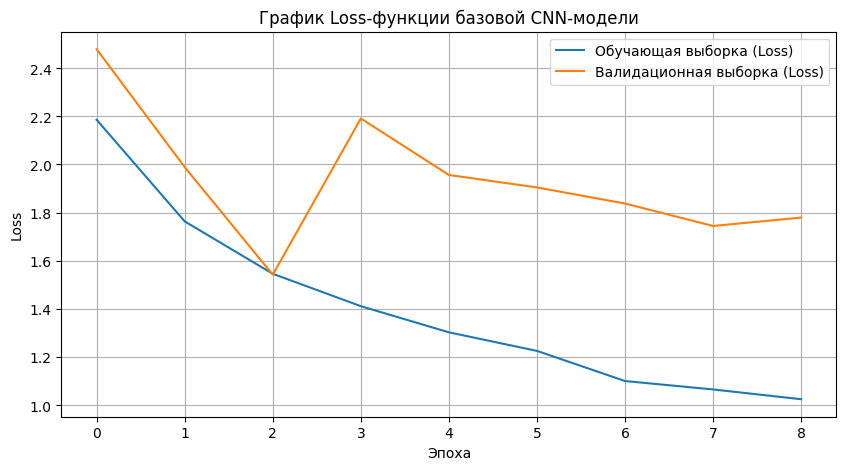

In [ ]:
#accuracy
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(history_1.history['loss'], label='Обучающая выборка (Loss)')
plt.plot(history_1.history['val_loss'], label='Валидационная выборка (Loss)')
plt.title('График Loss-функции базовой CNN-модели')
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

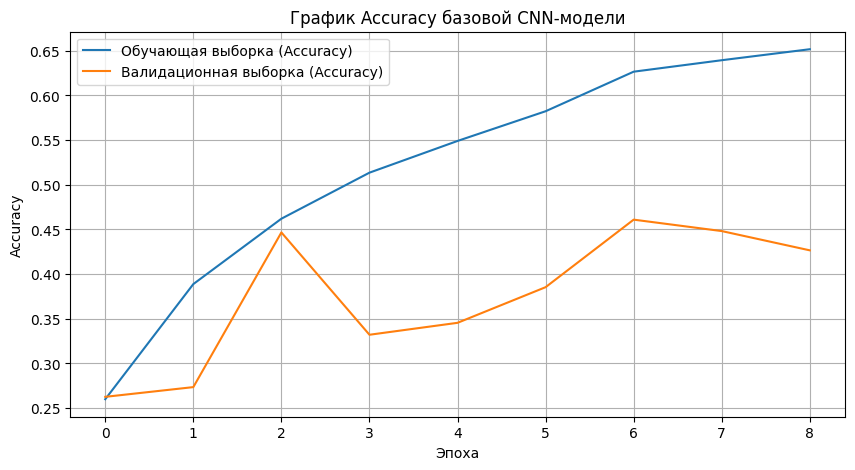

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(history_1.history['accuracy'], label='Обучающая выборка (Accuracy)')
plt.plot(history_1.history['val_accuracy'], label='Валидационная выборка (Accuracy)')
plt.title('График Accuracy базовой CNN-модели')
plt.xlabel('Эпоха')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
#оценка полученной модели
y_true_1 = []
y_pred_1 = []

start_inference = time.time()

for images, labels in val_ds:
    preds = model_1.predict(images, verbose=0)
    y_true_1.extend(labels.numpy())
    y_pred_1.extend(np.argmax(preds, axis=1))

end_inference = time.time()

inference_time_1 = end_inference - start_inference
fps_1 = len(y_true_1) / inference_time_1

accuracy_1 = accuracy_score(y_true_1, y_pred_1)
precision_1 = precision_score(y_true_1, y_pred_1, average='weighted')
recall_1 = recall_score(y_true_1, y_pred_1, average='weighted')
f1_1 = f1_score(y_true_1, y_pred_1, average='weighted')

print("Метрики базовой CNN-модели:")
print(f"--- Accuracy: {accuracy_1:.4f}")
print(f"--- Precision: {precision_1:.4f}")
print(f"--- Recall: {recall_1:.4f}")
print(f"--- F1-score: {f1_1:.4f}")
print(f"--- FPS: {fps_1:.2f} изображений/сек")

print("\nПодробный отчет по классам:")
print(classification_report(y_true_1, y_pred_1, target_names=class_names))

Метрики базовой CNN-модели:
--- Accuracy: 0.4466
--- Precision: 0.4959
--- Recall: 0.4466
--- F1-score: 0.4341
--- FPS: 419.22 изображений/сек

Подробный отчет по классам:
              precision    recall  f1-score   support

        cane       0.45      0.39      0.41       956
     cavallo       0.47      0.21      0.29       534
    elefante       0.52      0.10      0.17       256
    farfalla       0.80      0.57      0.66       406
     gallina       0.63      0.40      0.49       641
       gatto       0.36      0.09      0.14       303
       mucca       0.32      0.27      0.29       364
      pecora       0.20      0.71      0.31       363
       ragno       0.57      0.82      0.68      1025
  scoiattolo       0.45      0.31      0.37       387

    accuracy                           0.45      5235
   macro avg       0.48      0.39      0.38      5235
weighted avg       0.50      0.45      0.43      5235



In [12]:
#оптимизация модели

opt_input = layers.Input(shape=(*IMG_SIZE, 3))

# аугментация
z = layers.RandomFlip("horizontal")(opt_input)
z = layers.RandomRotation(0.04)(z)
z = layers.RandomZoom(0.04)(z)

#
z = layers.Conv2D(32, 3, padding="same")(z)
z = layers.BatchNormalization()(z)
z = layers.ReLU()(z)
z = layers.Conv2D(32, 3, padding="same")(z)
z = layers.BatchNormalization()(z)
z = layers.ReLU()(z)
z = layers.MaxPooling2D()(z)
z = layers.Dropout(0.10)(z)

#
z = layers.Conv2D(64, 3, padding="same")(z)
z = layers.BatchNormalization()(z)
z = layers.ReLU()(z)
z = layers.Conv2D(64, 3, padding="same")(z)
z = layers.BatchNormalization()(z)
z = layers.ReLU()(z)
z = layers.MaxPooling2D()(z)
z = layers.Dropout(0.15)(z)

#
z = layers.Conv2D(128, 3, padding="same")(z)
z = layers.BatchNormalization()(z)
z = layers.ReLU()(z)
z = layers.Conv2D(128, 3, padding="same")(z)
z = layers.BatchNormalization()(z)
z = layers.ReLU()(z)
z = layers.MaxPooling2D()(z)
z = layers.Dropout(0.25)(z)

# доп слой
z = layers.Conv2D(160, 3, padding="same")(z)
z = layers.BatchNormalization()(z)
z = layers.ReLU()(z)

#
z = layers.GlobalAveragePooling2D()(z)

# классификатор
z = layers.Dense(192)(z)
z = layers.BatchNormalization()(z)
z = layers.ReLU()(z)
z = layers.Dropout(0.35)(z)

z = layers.Dense(96)(z)
z = layers.BatchNormalization()(z)
z = layers.ReLU()(z)
z = layers.Dropout(0.25)(z)

opt_output = layers.Dense(num_classes, activation="softmax")(z)
model_2 = models.Model(opt_input, opt_output)
model_2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0003),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model_2.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip_2 (RandomFlip)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_2               │ (None, 128, 128, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_2 (RandomZoom)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_18 (ReLU)                 │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_19 (ReLU)                 │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_20 (ReLU)                 │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_21 (ReLU)                 │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_22          │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │             

 Total params: 525,482 (2.00 MB)

 Trainable params: 523,690 (2.00 MB)

 Non-trainable params: 1,792 (7.00 KB)

In [13]:
# улучшение модели
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop_2 = EarlyStopping(
    monitor="val_loss",
    patience=6,
    restore_best_weights=True
)

reduce_lr_2 = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

start_time = time.time()
history_2 = model_2.fit(
    train_ds,
    validation_data=val_ds,
    epochs=25,
    callbacks=[early_stop_2, reduce_lr_2],
    verbose=1
)

end_time = time.time()
train_time_2 = end_time - start_time
print(f"Обучение оптимизированной модели завершено за {train_time_2:.2f} секунд")

Epoch 1/25
328/328 ━━━━━━━━━━━━━━━━━━━━ 78s 215ms/step - accuracy: 0.2909 - loss: 2.0407 - val_accuracy: 0.1003 - val_loss: 3.9976 - learning_rate: 3.0000e-04
Epoch 2/25
328/328 ━━━━━━━━━━━━━━━━━━━━ 69s 212ms/step - accuracy: 0.4060 - loss: 1.6939 - val_accuracy: 0.3471 - val_loss: 1.9311 - learning_rate: 3.0000e-04
Epoch 3/25
328/328 ━━━━━━━━━━━━━━━━━━━━ 69s 210ms/step - accuracy: 0.4712 - loss: 1.5078 - val_accuracy: 0.3425 - val_loss: 2.0402 - learning_rate: 3.0000e-04
Epoch 4/25
328/328 ━━━━━━━━━━━━━━━━━━━━ 69s 210ms/step - accuracy: 0.5316 - loss: 1.3623 - val_accuracy: 0.4189 - val_loss: 1.7883 - learning_rate: 3.0000e-04
Epoch 5/25
328/328 ━━━━━━━━━━━━━━━━━━━━ 83s 212ms/step - accuracy: 0.5719 - loss: 1.2510 - val_accuracy: 0.4248 - val_loss: 1.8803 - learning_rate: 3.0000e-04
Epoch 6/25
328/328 ━━━━━━━━━━━━━━━━━━━━ 69s 210ms/step - accuracy: 0.5931 - loss: 1.1819 - val_accuracy: 0.3412 - val_loss: 2.1295 - learning_rate: 3.0000e-04
Epoch 7/25
328/328 ━━━━━━━━━━━━━━━━━━━━ 69s 20

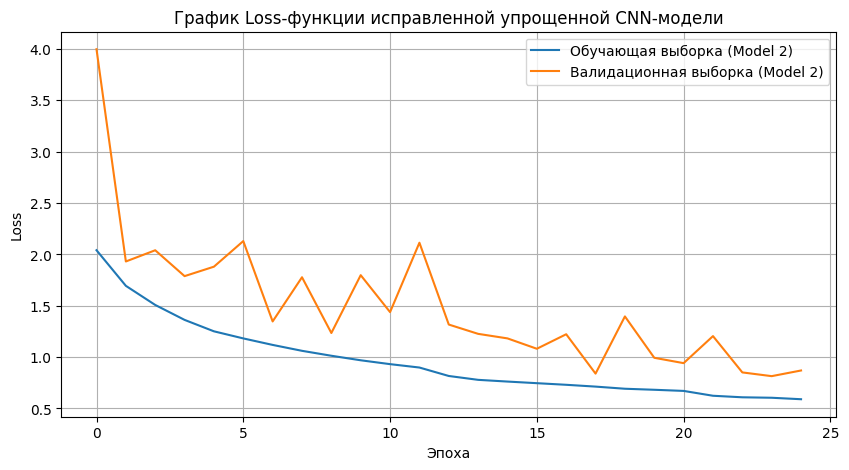

In [14]:
plt.figure(figsize=(10, 5))
plt.plot(history_2.history['loss'], label='Обучающая выборка (Model 2)')
plt.plot(history_2.history['val_loss'], label='Валидационная выборка (Model 2)')
plt.title('График Loss-функции исправленной упрощенной CNN-модели')
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

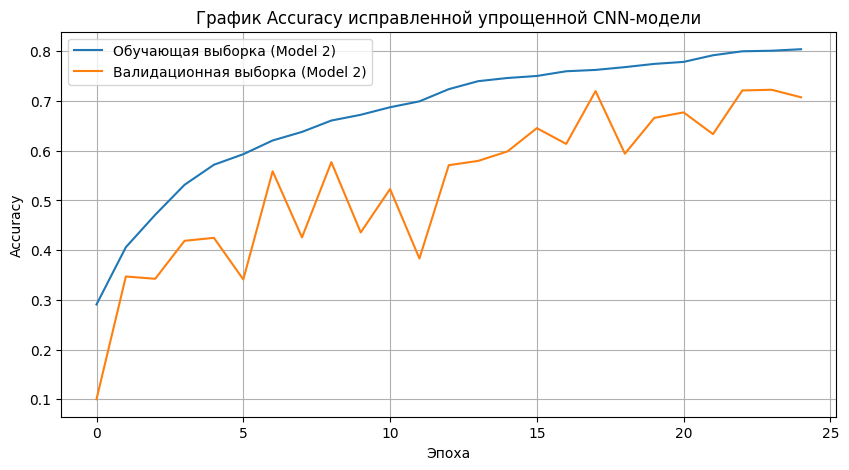

In [15]:
plt.figure(figsize=(10, 5))
plt.plot(history_2.history['accuracy'], label='Обучающая выборка (Model 2)')
plt.plot(history_2.history['val_accuracy'], label='Валидационная выборка (Model 2)')
plt.title('График Accuracy исправленной упрощенной CNN-модели')
plt.xlabel('Эпоха')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

In [16]:
y_true_2 = []
y_pred_2 = []

start_inference = time.time()

for images, labels in val_ds:
    preds = model_2.predict(images, verbose=0)
    y_true_2.extend(labels.numpy())
    y_pred_2.extend(np.argmax(preds, axis=1))

end_inference = time.time()

inference_time_2 = end_inference - start_inference
fps_2 = len(y_true_2) / inference_time_2

accuracy_2 = accuracy_score(y_true_2, y_pred_2)
precision_2 = precision_score(y_true_2, y_pred_2, average='weighted', zero_division=0)
recall_2 = recall_score(y_true_2, y_pred_2, average='weighted', zero_division=0)
f1_2 = f1_score(y_true_2, y_pred_2, average='weighted', zero_division=0)

print("Метрики исправленной упрощенной CNN-модели:")
print(f"--- Accuracy: {accuracy_2:.4f}")
print(f"--- Precision: {precision_2:.4f}")
print(f"--- Recall: {recall_2:.4f}")
print(f"--- F1-score: {f1_2:.4f}")
print(f"--- FPS: {fps_2:.2f} изображений/сек")

print("\nПодробный отчет по классам:")
print(classification_report(
    y_true_2,
    y_pred_2,
    target_names=class_names,
    zero_division=0
))

Метрики исправленной упрощенной CNN-модели:
--- Accuracy: 0.7226
--- Precision: 0.7705
--- Recall: 0.7226
--- F1-score: 0.7284
--- FPS: 496.61 изображений/сек

Подробный отчет по классам:
              precision    recall  f1-score   support

        cane       0.82      0.65      0.72       956
     cavallo       0.84      0.66      0.74       534
    elefante       0.60      0.80      0.68       256
    farfalla       0.69      0.90      0.78       406
     gallina       0.93      0.72      0.81       641
       gatto       0.47      0.57      0.52       303
       mucca       0.59      0.68      0.63       364
      pecora       0.43      0.85      0.57       363
       ragno       0.88      0.86      0.87      1025
  scoiattolo       0.91      0.43      0.58       387

    accuracy                           0.72      5235
   macro avg       0.72      0.71      0.69      5235
weighted avg       0.77      0.72      0.73      5235



In [18]:
comparison = pd.DataFrame({
    "Параметр": [
        "Архитектура",
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "FPS",
        "Время обучения (сек)",
        "Количество параметров"
    ],

    "Модель №1 (Base CNN)": [
        "Aug → Conv32x2 → Conv64x2 → Conv128x2 → Conv192 → GAP → Dense256 → Dense128",
        round(accuracy_1, 4),
        round(precision_1, 4),
        round(recall_1, 4),
        round(f1_1, 4),
        round(fps_1, 2),
        round(train_time_1, 2),
        model_1.count_params()
    ],

    "Модель №2 (Optimized CNN)": [
        "Aug → Conv32x2 → Conv64x2 → Conv128x2 → Conv160 → GAP → Dense192 → Dense96",
        round(accuracy_2, 4),
        round(precision_2, 4),
        round(recall_2, 4),
        round(f1_2, 4),
        round(fps_2, 2),
        round(train_time_2, 2),
        model_2.count_params()
    ]
})

comparison

,Параметр,Модель №1 (Base CNN),Модель №2 (Optimized CNN)
0,Архитектура,Aug → Conv32x2 → Conv64x2 → Conv128x2 → Conv19...,Aug → Conv32x2 → Conv64x2 → Conv128x2 → Conv16...
1,Accuracy,0.4466,0.7226
2,Precision,0.4959,0.7705
3,Recall,0.4466,0.7226
4,F1-score,0.4341,0.7284
5,FPS,419.22,496.61
6,Время обучения (сек),659.34,1743.81
7,Количество параметров,596074,525482


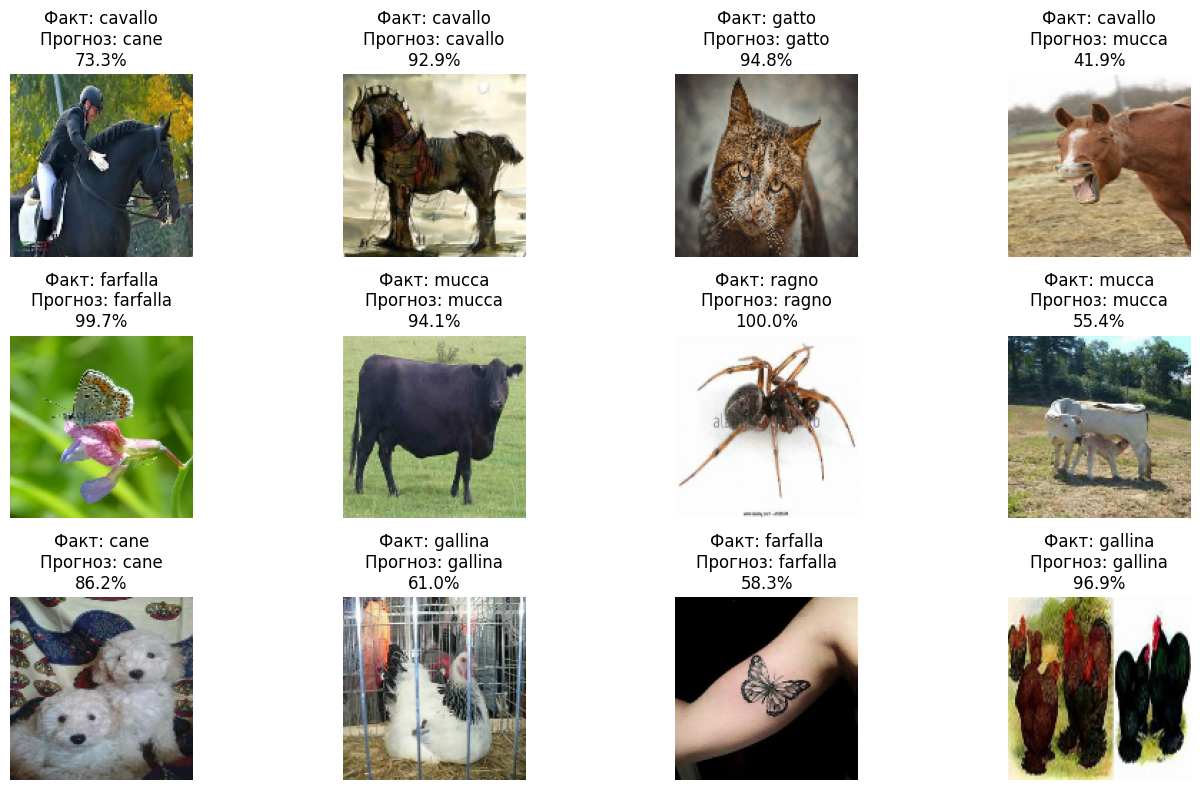

In [20]:
# проверка модели на отдельных изображениях

plt.figure(figsize=(14, 8))

for i in range(12):
    predicted_class = np.argmax(predictions[i])
    true_class = test_labels[i].numpy()
    confidence = np.max(predictions[i]) * 100

    plt.subplot(3, 4, i + 1)

    img = test_images[i]
    if tf.reduce_max(img) > 1:
        img = img / 255.0

    plt.imshow(img)
    plt.title(
        f"Факт: {class_names[true_class]}\n"
        f"Прогноз: {class_names[predicted_class]}\n"
        f"{confidence:.1f}%"
    )

    plt.axis("off")
plt.tight_layout()
plt.show()